# Prosser (2023) — per-diagnostic replication

Reads the archived CSV reductions in `data_prosser/` and compares them against the
values printed inside Prosser's own Figure 4 panels.

**What is exact and what is not.** Prosser prints `rel=`, `abs=` and `p=` in every
panel of Figure 4, so the *trend* and *significance* comparisons are exact. The
1979 *levels* are read off the position of his red crosses and are good to about
±0.02 — fine for ratios, not for a precise claim. Table 1 is tabulated in the
paper and is exact; it is scored separately by `ada/prosser_scorecard.py`.

Nothing here recomputes anything from ERA5. The fits come from
`ada/prosser_figures.py`, the same code that produced the archived figures, so
this notebook cannot disagree with them.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd()                      # run this notebook from the repo root
DATA = REPO / "data_prosser"           # where the CSVs from ADA live
sys.path.insert(0, str(REPO / "ada"))

import prosser_figures as pf           # the fitting + panel code, reused
from prosser_published import (FIGURE4, FIGURE4_SUMMARY, FIGURE4_YLIM,
                               USES_VERTICAL_STENCIL)

SEVERITY = "moderate"                  # Prosser's Figure 4 is annual MOG
series_path = DATA / f"per_diagnostic_annual_{SEVERITY}_series.csv"
years, data = pf.read_series(series_path)
fits = {n: pf.fit_summary(years, v) for n, v in data.items()}
print(f"{len(years)} years, {len(data)-1} diagnostics, {years[0]:.0f}-{years[-1]:.0f}")

42 years, 21 diagnostics, 1979-2020


## 1. The ensemble

Our diagnostic-mean annual MOG probability against Prosser's Table 1 annual row.

ours    +36.2%  95% CI [+23%, +50%]  t=5.36  R2=0.42
Prosser +37%   inside our CI: True
level   ours 0.672% -> 0.915%;  Prosser 0.799% in 1979


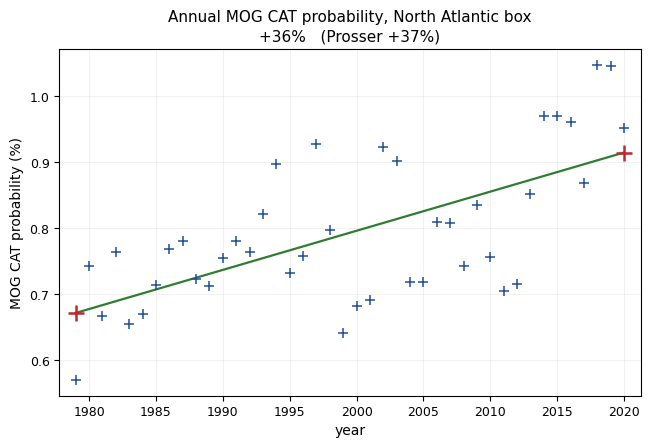

In [2]:
s = fits["ensemble"]
print(f"ours    {s['rel']:+.1%}  95% CI [{s['lo']:+.0%}, {s['hi']:+.0%}]  "
      f"t={s['fit']['t']:.2f}  R2={s['fit']['r2']:.2f}")
print(f"Prosser {pf.PROSSER_ANNUAL_REL[SEVERITY]:+.0%}   "
      f"inside our CI: {s['lo'] <= pf.PROSSER_ANNUAL_REL[SEVERITY] <= s['hi']}")
print(f"level   ours {s['y0']:.3%} -> {s['y1']:.3%};  "
      f"Prosser {pf.PROSSER_ANNUAL_HOURS_1979[SEVERITY]/8766:.3%} in 1979")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
pf._panel(ax, years, data["ensemble"], s, "Annual MOG CAT probability, North Atlantic box",
          show_prosser=pf.PROSSER_ANNUAL_REL[SEVERITY])
ax.set_xlabel("year"); ax.set_ylabel("MOG CAT probability (%)")
plt.show()

## 2. Every diagnostic against his printed panel values

`trend_ratio` is ours ÷ his on the relative change; `level_ratio` is ours ÷ his on
the 1979 level. `stencil` marks the ten diagnostics that use the 175/225 hPa
vertical stencil — the ones the level substitution can actually reach.

In [3]:
TC = pf.tcrit(len(years) - 2)
rows = []
for n, (panel, title, rel, abs_, p, lvl) in FIGURE4.items():
    f = fits[n]
    rows.append(dict(
        diagnostic=n, panel=panel, stencil=USES_VERTICAL_STENCIL[n],
        ours_pct=f["rel"] * 100, his_pct=rel,
        trend_ratio=(f["rel"] * 100 / rel) if rel else np.nan,
        ours_level=f["y0"] * 100, his_level=lvl,
        level_ratio=f["y0"] * 100 / lvl,
        ours_sig=f["significant"], his_sig=p < 0.05,
        t=f["fit"]["t"], his_p=p))

cmp = pd.DataFrame(rows).set_index("diagnostic")
cmp["agree_sig"] = cmp.ours_sig == cmp.his_sig
cmp = cmp.sort_values("level_ratio")
cmp.round(3)

,panel,stencil,ours_pct,his_pct,trend_ratio,ours_level,his_level,level_ratio,ours_sig,his_sig,t,his_p,agree_sig
diagnostic,,,,,,,,,,,,,
colson_panofsky,c,True,62.309,45.4,1.372,0.039,0.285,0.138,False,True,1.852,0.002,False
ubf,q,False,19.951,31.6,0.631,0.139,0.720,0.193,True,True,2.326,0.000,True
f2d,d,True,26.213,0.3,87.376,0.023,0.055,0.425,False,False,0.812,1.000,True
negative_richardson,a,True,40.572,-7.5,-5.410,0.019,0.039,0.494,False,False,1.000,0.600,True
endlich,n,True,37.672,27.7,1.360,0.470,0.920,0.511,True,True,5.222,0.000,True
magnitude_pv,j,False,25.972,50.6,0.513,0.993,1.620,0.613,False,True,1.973,0.000,False
ngm2,p,True,27.970,33.8,0.828,0.147,0.240,0.615,True,True,2.491,0.001,True
vertical_wind_shear,b,True,39.010,38.4,1.016,1.429,1.680,0.850,True,True,5.074,0.000,True
ti2,h,True,28.676,27.0,1.062,1.190,1.370,0.868,True,True,4.332,0.000,True


In [4]:
# the three numbers Prosser states in his text — the exact check on Figure 4
n_sig = int(cmp.ours_sig.sum())
print(f"significant     ours {n_sig}/21      Prosser {FIGURE4_SUMMARY['n_significant']}/21")
print(f"largest change  ours {cmp.ours_pct.max():+.1f}%   Prosser {FIGURE4_SUMMARY['max_change']:+.1f}%")
print(f"significant DOWNWARD  ours {int(((cmp.ours_pct < 0) & cmp.ours_sig).sum())}   Prosser 0")
print(f"\nsignificance agrees on {int(cmp.agree_sig.sum())}/21")
print("disagreements:", list(cmp.index[~cmp.agree_sig]))

significant     ours 16/21      Prosser 17/21
largest change  ours +73.9%   Prosser +75.6%
significant DOWNWARD  ours 0   Prosser 0

significance agrees on 18/21
disagreements: ['colson_panofsky', 'magnitude_pv', 'ncsu1']


## 3. The stencil test

The project's standing explanation for its 12–20 % level deficit is the vertical
stencil: we differentiate across 175→225 hPa (50 hPa), Prosser across 188→206
(18 hPa). `PLAN_full_year_calibration.md` §4 pointed out that this explanation can
only reach **ten of the twenty-one** diagnostics, and that if the deficit were
spread evenly across both groups the explanation would be falsified.

This is that test.

In [5]:
g = cmp.groupby("stencil")[["level_ratio", "trend_ratio"]].median()
g.index = ["single-level (11)", "uses 175/225 stencil (10)"]
print(g.round(3), "\n")

for label, sel in [("single-level", ~cmp.stencil), ("stencil", cmp.stencil)]:
    sub = cmp[sel].sort_values("level_ratio")
    print(f"{label}: " + ", ".join(f"{i} {r:.2f}" for i, r in sub.level_ratio.items()))

                           level_ratio  trend_ratio
single-level (11)                0.934        0.987
uses 175/225 stencil (10)        0.732        1.053 

single-level: ubf 0.19, magnitude_pv 0.61, horizontal_divergence 0.87, rva_magnitude 0.90, temperature_gradient 0.91, ngm1 0.93, wind_speed 0.94, nva 0.97, deformation 1.00, brown1 1.09, vorticity_squared 1.12
stencil: colson_panofsky 0.14, f2d 0.43, negative_richardson 0.49, endlich 0.51, ngm2 0.61, vertical_wind_shear 0.85, ti2 0.87, ti1 0.88, brown2 0.91, ncsu1 6.07


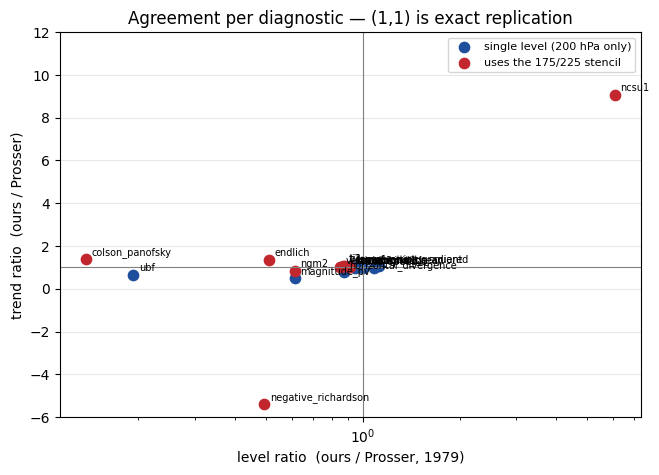

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for stencil, colour, label in [(False, "#1f4e9c", "single level (200 hPa only)"),
                               (True, "#c1272d", "uses the 175/225 stencil")]:
    sub = cmp[cmp.stencil == stencil]
    ax.scatter(sub.level_ratio, sub.trend_ratio, c=colour, label=label, s=55)
    for name, r in sub.iterrows():
        ax.annotate(name, (r.level_ratio, r.trend_ratio), fontsize=7,
                    xytext=(4, 3), textcoords="offset points")
ax.axvline(1, color="grey", lw=0.8); ax.axhline(1, color="grey", lw=0.8)
ax.set_xlabel("level ratio  (ours / Prosser, 1979)")
ax.set_ylabel("trend ratio  (ours / Prosser)")
ax.set_title("Agreement per diagnostic — (1,1) is exact replication")
ax.set_xscale("log"); ax.set_ylim(-6, 12); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()

## 4. Our 21 panels, drawn on Prosser's axes

Set `MATCH_AXES = True` to force each panel onto the y-range of his corresponding
panel, so the two figures can be laid side by side. Where our panel then goes
blank or the points pile against an edge, the *level* disagrees — which is
information, not a plotting bug.

In [7]:
MATCH_AXES = True   # False -> our own scales, for reading the shape

out, offscale = pf.figure_prosser_layout(
    years, data, DATA / "figures", FIGURE4, FIGURE4_YLIM, match_axes=MATCH_AXES)
print("wrote", out)

# which panels do not fit his axis, and materially so
mat = {k: v for k, v in offscale.items()
       if v["fit_out"] or v["n_out"] > 0.1 * len(years)}
pd.DataFrame([
    dict(diagnostic=k, points_off=v["n_out"], fitted_line_off=v["fit_out"],
         ours_lo=round(v["ours"][0], 3), ours_hi=round(v["ours"][1], 3),
         his_lo=v["his"][0], his_hi=v["his"][1])
    for k, v in sorted(mat.items(), key=lambda kv: -kv[1]["n_out"])])

wrote c:\Users\yanni\OneDrive\Documenten\GitHub\data_turbulence\data_prosser\figures\fig4_prosser_layout_his_axes.png


,diagnostic,points_off,fitted_line_off,ours_lo,ours_hi,his_lo,his_hi
0,colson_panofsky,42,True,0.020,0.125,0.200,0.600
1,ubf,42,True,0.116,0.225,0.600,1.100
2,ncsu1,42,True,0.378,0.715,0.030,0.110
3,endlich,40,True,0.357,0.782,0.700,1.500
4,f2d,21,True,0.003,0.085,0.025,0.085
5,rva_magnitude,16,True,0.611,1.175,0.800,1.400
6,magnitude_pv,13,True,0.502,1.609,1.000,3.000
7,negative_richardson,9,False,0.005,0.079,0.010,0.060
8,ti2,9,True,1.069,1.836,1.200,2.000


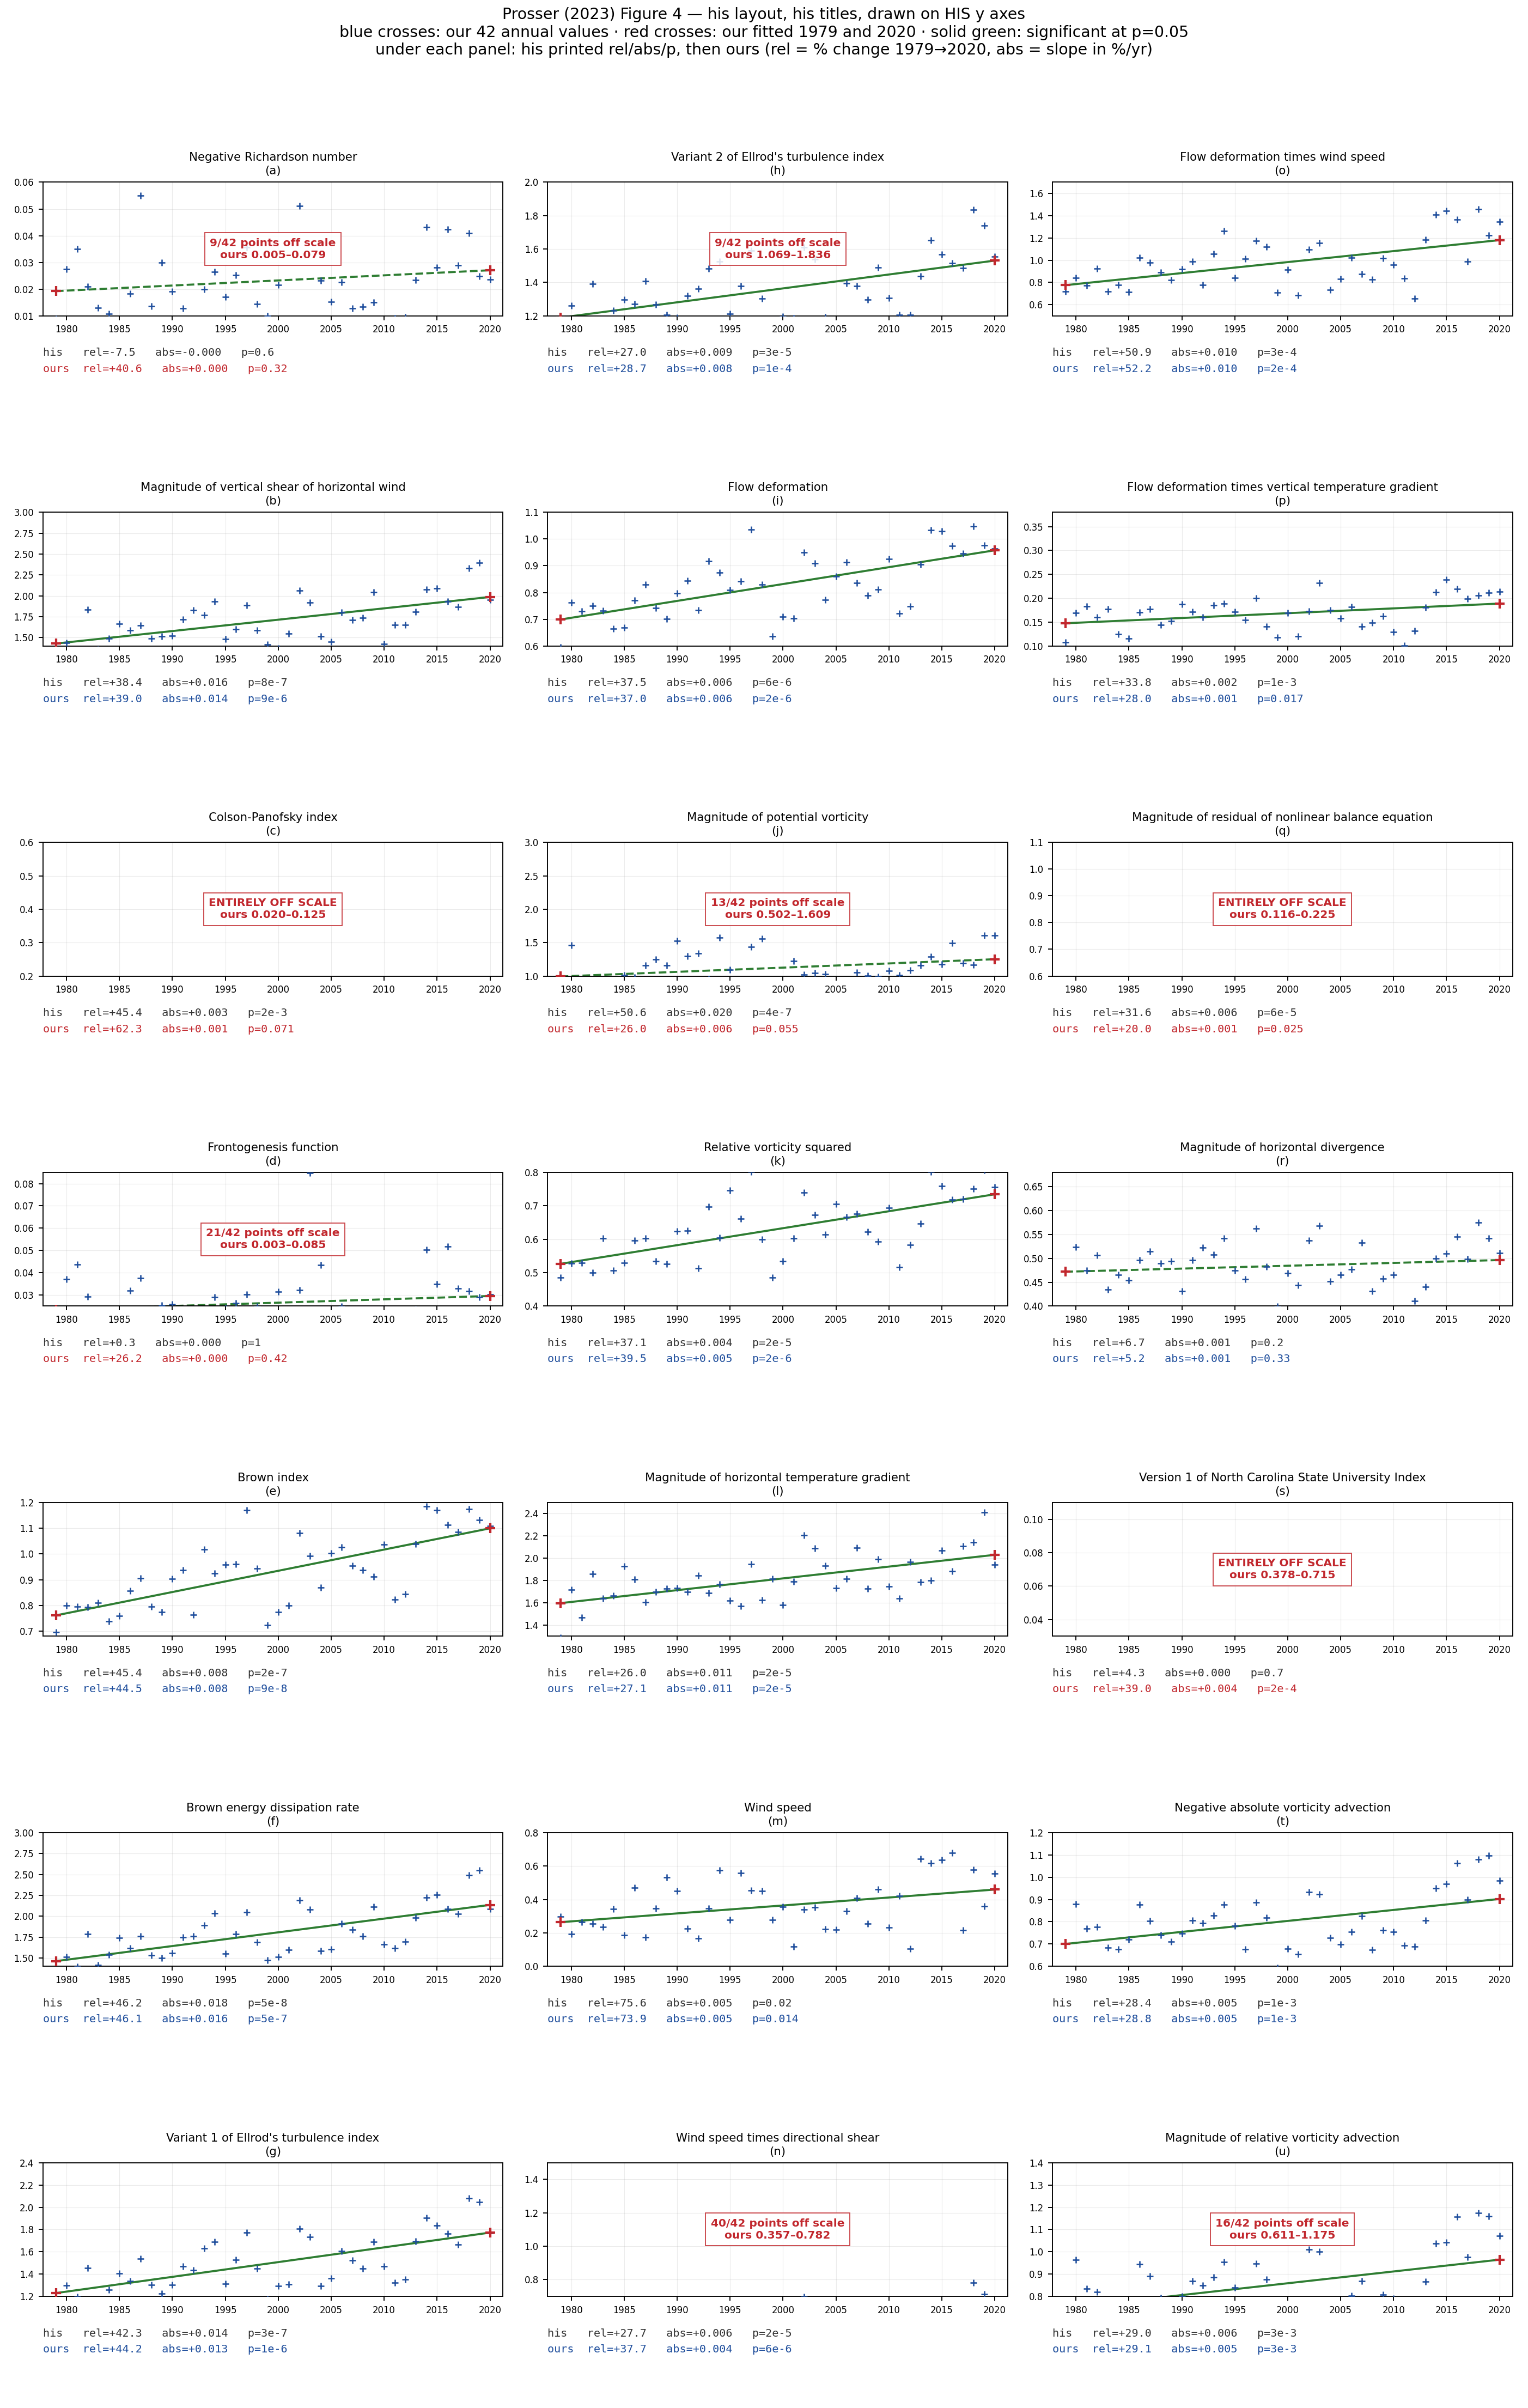

In [8]:
from IPython.display import Image, display
display(Image(filename=str(DATA / "figures" /
              f"fig4_prosser_layout_{'his' if MATCH_AXES else 'our'}_axes.png")))

## 5. Where to look next

- **The 5 disagreements are not spread randomly.** Check whether they line up with
  `STATUS.md` §7's open literature items — the `ncsu1`/`nva` `max(·,0)` clipping
  question, `f2d`'s leading minus sign, and the Richardson-based pair.
- **A level ratio far from 1 with a trend ratio near 1** is the benign case: a
  scaling that cancels out of the change (`RESULT_full_trend_42yr.md` §2).
- **A trend ratio far from 1** is the case that matters, because the trend is what
  the project claims.
- To regenerate the archived figures deterministically rather than exploring:
  `python ada/prosser_figures.py --outputs data_prosser`
